In [2]:
from transformers import pipeline, Pipeline
from PIL import Image as PILImageModule
from PIL.Image import Image
import numpy.typing as npt
import numpy as np

/mnt/perma/bin/miniconda3/envs/depthedit/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
image: Image = PILImageModule.open("datasets/csc2529/background/0.png")

In [4]:
# depth_pipe = pipeline(
#     task="depth-estimation", model="LiheYoung/depth-anything-small-hf"
# )

# depth = depth_pipe(image)["depth"]
# depth.show()

In [5]:
sam_model = pipeline("mask-generation", model="facebook/sam-vit-huge", device=0)

In [6]:
def get_object_mask(image: npt.NDArray, pt: npt.NDArray, sam_model: Pipeline) -> npt.NDArray:
    outputs = sam_model(image, points_per_batch=64)
    masks = outputs["masks"]
    x,y=pt
    for mask in masks:
        if mask[y,x] == 1:
            return mask
    else:
        raise RuntimeError("SAM couldn't find an object at the given point")

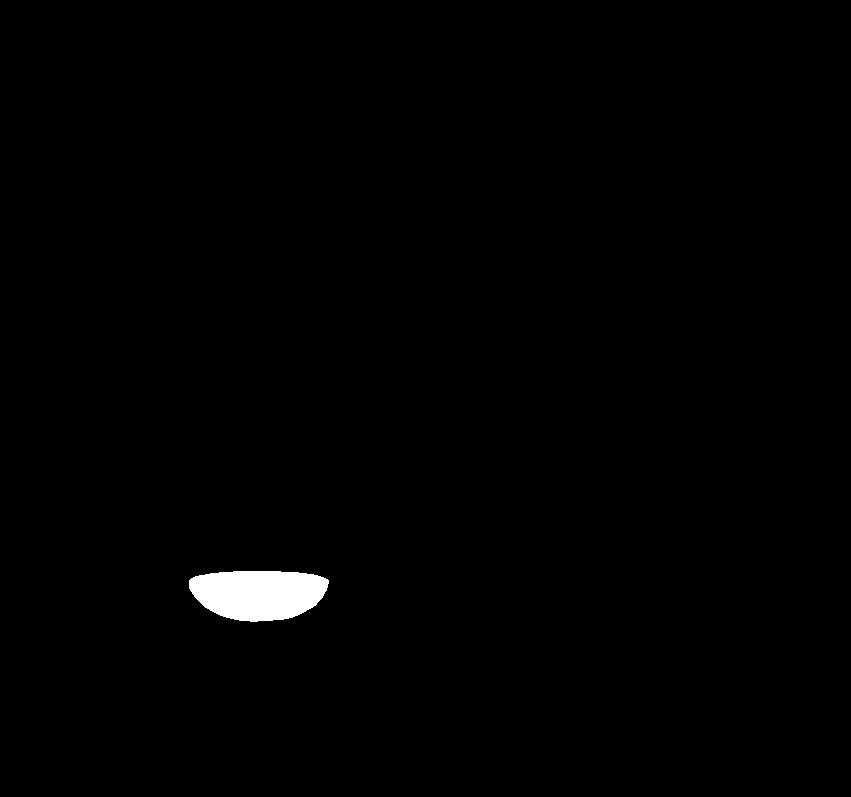

In [ ]:
x = 270
y = 600
mask = get_object_mask(image, np.array([x,y]), sam_model)
pil_mask = PILImageModule.fromarray(mask)
pil_mask.show()

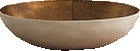

In [8]:
extracted = image.copy()
extracted.putalpha(pil_mask)

bbox = pil_mask.getbbox()
extracted = extracted.crop(bbox)
extracted.show()

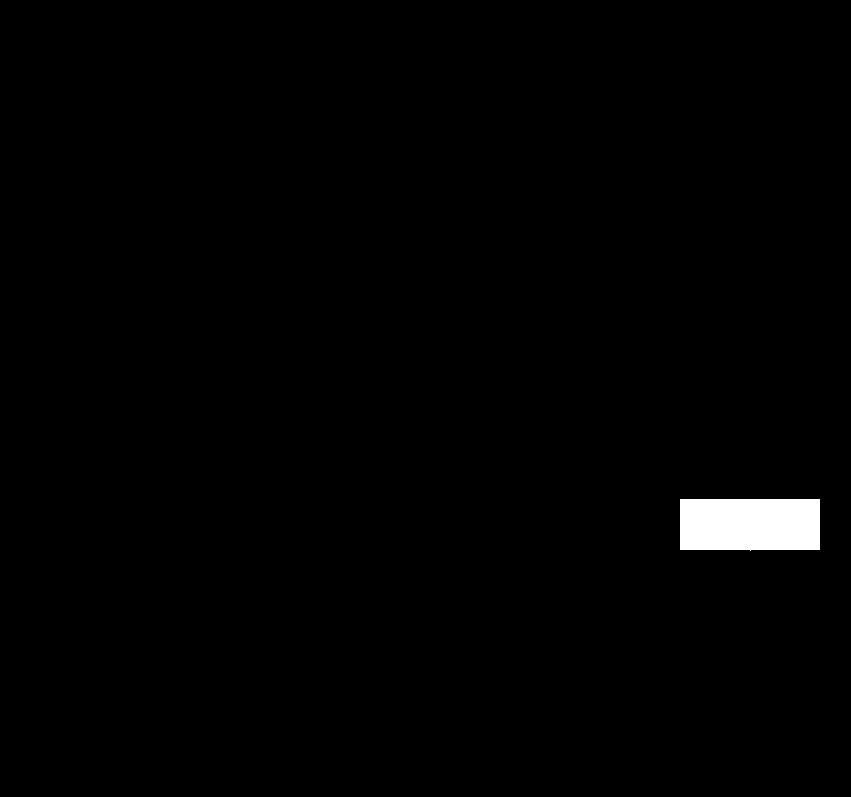

In [18]:
def calc_target_mask(image: npt.NDArray, target_px: npt.NDArray, source_object: npt.NDArray) -> npt.NDArray:
    h, w = source_object.shape[0:2]
    tx, ty = target_px
    target_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    target_mask[ty-h:ty, tx-w//2 : tx+w//2] = 255
    target_mask[ty,tx] = 255
    return target_mask


target_mask = calc_target_mask(np.asarray(image), np.array([750,550]), np.asarray(extracted))
PILImageModule.fromarray(target_mask, mode="L").show()